<a href="https://colab.research.google.com/github/samaandrea10/Mortgage-Approval-Prediction/blob/main/Mortgage_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mortgage Approval Prediction Using Machine Learning


This notebook presents the complete development process of a machine learning model for predicting mortgage approval decisions using the HMDA 2023 dataset.

The project follows the CRISP-DM methodology and includes:

- Data loading and exploration
- Data preprocessing
- Feature selection
- Model training
- Model evaluation
- Hyperparameter tuning
- Fairness analysis
- Model deployment preparation

## 1. Import Required Libraries

The following libraries are imported to support all stages of the project, including:

- Data manipulation
- Data visualization
- Data preprocessing
- Machine learning model development
- Model evaluation
- Model persistence for deployment

## 1. Importing Libraries

In this section, the main Python libraries required for the project are imported.  
Pandas and NumPy are used for data processing, Matplotlib and Seaborn are used for visualization, and Scikit-learn is used for preprocessing, model training and evaluation.

The Joblib library will be used at the end of the project to save the final trained model for integration into the Streamlit application.

In [4]:
# Libraries for data analysis
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tools for splitting the data and evaluating the models
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Saving the final model
import joblib

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries were imported successfully.")

Libraries were imported successfully.


## 2. Data Loading

In this step, the HMDA 2023 dataset is loaded into a Pandas DataFrame.

This dataset contains mortgage application records submitted by financial institutions across the United States. It will serve as the main data source for building and evaluating the mortgage approval prediction model.

In [5]:
# Load the HMDA 2023 dataset
df = pd.read_csv("hmda_2023_processed.csv")
# Display the dataset dimensions
print(f"Dataset shape: {df.shape}")

# Preview the first five rows
df.head()

Dataset shape: (50000, 13)


,loan_amount,income,interest_rate,loan_to_value_ratio,debt_to_income_ratio,property_value,loan_term,applicant_age,derived_race,derived_sex,derived_ethnicity,action_taken,target
0,55000,129.0,NaN,54.071,>60%,475000,360,45-54,White,Male,Not Hispanic or Latino,3,0
1,285000,151.0,NaN,75,30%-<36%,385000,360,35-44,Asian,Male,Hispanic or Latino,3,0
2,65000,363.0,NaN,100.028,NaN,765000,360,45-54,Joint,Joint,Not Hispanic or Latino,3,0
3,105000,59.0,NaN,55.103,>60%,525000,480,45-54,White,Female,Hispanic or Latino,3,0
4,65000,242.0,NaN,75.833,<20%,505000,180,35-44,Black or African American,Male,Ethnicity Not Available,3,0


## 3. Exploratory Data Analysis (EDA)

The purpose of this stage is to gain an initial understanding of the dataset before any preprocessing or modeling is performed.

During the exploratory analysis, the following aspects are examined:

- Dataset dimensions
- Data types
- Missing values
- Summary statistics
- Distribution of the target variable
- Distribution of selected numerical features

This analysis helps identify potential data quality issues and supports informed decisions during the preprocessing stage.

### 3.1 Dataset Preview

The first few records are displayed to verify that the dataset was loaded correctly and to obtain an initial understanding of its structure.

In [6]:
df.head()

,loan_amount,income,interest_rate,loan_to_value_ratio,debt_to_income_ratio,property_value,loan_term,applicant_age,derived_race,derived_sex,derived_ethnicity,action_taken,target
0,55000,129.0,NaN,54.071,>60%,475000,360,45-54,White,Male,Not Hispanic or Latino,3,0
1,285000,151.0,NaN,75,30%-<36%,385000,360,35-44,Asian,Male,Hispanic or Latino,3,0
2,65000,363.0,NaN,100.028,NaN,765000,360,45-54,Joint,Joint,Not Hispanic or Latino,3,0
3,105000,59.0,NaN,55.103,>60%,525000,480,45-54,White,Female,Hispanic or Latino,3,0
4,65000,242.0,NaN,75.833,<20%,505000,180,35-44,Black or African American,Male,Ethnicity Not Available,3,0


### 3.2 Dataset Dimensions

The following output shows the number of observations and features included in the dataset.

In [7]:
rows, cols = df.shape

print(f"Number of records : {rows:,}")
print(f"Number of features: {cols}")

Number of records : 50,000
Number of features: 13


### 3.3 Feature Names

The dataset contains information about mortgage applications, applicant characteristics, property details and financial variables collected through the HMDA reporting system.

Reviewing the available variables helps identify the features that may contribute to predicting mortgage approval decisions.

In [8]:
df.columns.tolist()

['loan_amount',
 'income',
 'interest_rate',
 'loan_to_value_ratio',
 'debt_to_income_ratio',
 'property_value',
 'loan_term',
 'applicant_age',
 'derived_race',
 'derived_sex',
 'derived_ethnicity',
 'action_taken',
 'target']

### 3.4 Data Types

Understanding the data types of each variable is an important step before preprocessing. Numerical and categorical features require different preprocessing techniques such as scaling, encoding and missing value imputation.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amount           50000 non-null  int64  
 1   income                48226 non-null  float64
 2   interest_rate         35633 non-null  object 
 3   loan_to_value_ratio   48302 non-null  object 
 4   debt_to_income_ratio  47852 non-null  object 
 5   property_value        48947 non-null  object 
 6   loan_term             49545 non-null  object 
 7   applicant_age         50000 non-null  object 
 8   derived_race          50000 non-null  object 
 9   derived_sex           50000 non-null  object 
 10  derived_ethnicity     50000 non-null  object 
 11  action_taken          50000 non-null  int64  
 12  target                50000 non-null  int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 5.0+ MB


### 3.5 Missing Values

Missing values are examined to identify variables that require cleaning or imputation before training the machine learning models.

In [10]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values[missing_values > 0]

,0
interest_rate,14367
debt_to_income_ratio,2148
income,1774
loan_to_value_ratio,1698
property_value,1053
loan_term,455


### 3.6 Summary Statistics

Descriptive statistics are calculated for the numerical variables to better understand their distributions, central tendency and variability before the preprocessing stage.

In [11]:
df.describe()

,loan_amount,income,action_taken,target
count,5.000000e+04,48226.000000,50000.000000,50000.00000
mean,2.829381e+05,148.304566,1.584800,0.70760
std,2.231491e+06,292.320386,0.909739,0.45487
min,5.000000e+03,-1803.000000,1.000000,0.00000
25%,7.500000e+04,69.000000,1.000000,0.00000
50%,1.550000e+05,106.000000,1.000000,1.00000
75%,3.050000e+05,165.000000,3.000000,1.00000
max,1.800000e+08,24735.000000,3.000000,1.00000


### 3.7 Target Variable Distribution

The distribution of mortgage approval decisions is examined in order to understand the balance between approved and denied applications before model training.

In [12]:
df["action_taken"].value_counts()

,count
action_taken,
1,35380
3,14620


### 3.8 Distribution of Selected Numerical Features

The distributions of selected numerical variables are examined to better understand their range and identify potential outliers.

## 4. Exploratory Analysis of Mortgage Approval

## 4.1 Distribution of Mortgage Decisions

Before building the prediction models, it is important to examine the distribution of mortgage application outcomes.

For this project, the analysis focuses only on applications with a final lending decision: **Approved** and **Denied**.

This visualization helps identify whether the target classes are balanced before training the machine learning models.

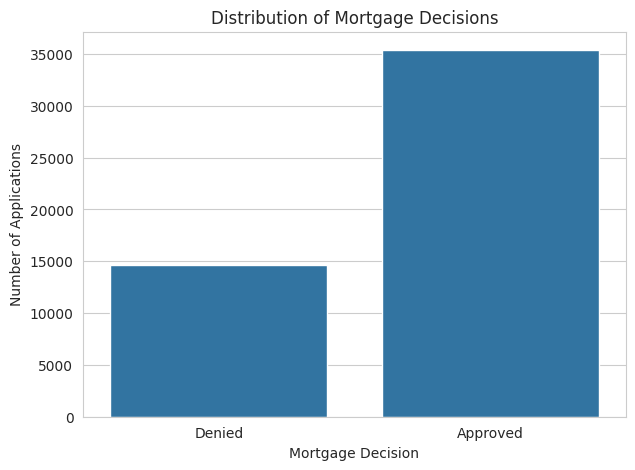

In [13]:
# Keep only final mortgage decisions
decision_data = df[df["action_taken"].isin([1, 3])]

plt.figure(figsize=(7,5))

sns.countplot(
    data=decision_data,
    x="action_taken",
    order=[3, 1]
)

plt.xticks(
    ticks=[0, 1],
    labels=["Denied", "Approved"]
)

plt.title("Distribution of Mortgage Decisions")
plt.xlabel("Mortgage Decision")
plt.ylabel("Number of Applications")

plt.show()

## 4.2 Relationship Between Features and Mortgage Approval

After examining the overall distribution of mortgage decisions, the next step is to explore how selected applicant and loan characteristics relate to the approval outcome.

The following visualizations provide an initial understanding of the relationship between key features and mortgage approval before building the machine learning models.

### 4.2.1 Income vs Mortgage Approval

Income is an important financial variable in the mortgage approval process. The following boxplot compares applicant income between approved and denied applications.

In [14]:
df = df[df["action_taken"].isin([1, 3])].copy()

df["approved"] = df["action_taken"].map({
    1: 1,
    3: 0
})

In [15]:
print(df["approved"].value_counts())

approved
1    35380
0    14620
Name: count, dtype: int64


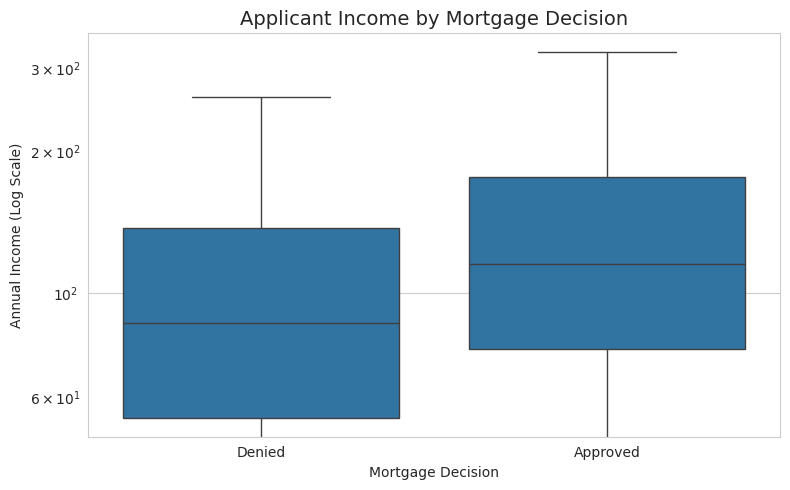

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="approved",
    y="income",
    showfliers=False
)

plt.yscale("log")

plt.xticks([0,1],["Denied","Approved"])

plt.title("Applicant Income by Mortgage Decision", fontsize=14)
plt.xlabel("Mortgage Decision")
plt.ylabel("Annual Income (Log Scale)")

plt.tight_layout()
plt.show()

### 4.2.2 Median Income by Mortgage Decision

Applicant income contains several extreme values, so the median provides a more reliable comparison than the mean.

The following chart compares the median annual income of applicants whose mortgage applications were approved and denied.

/tmp/ipykernel_1298/866073874.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


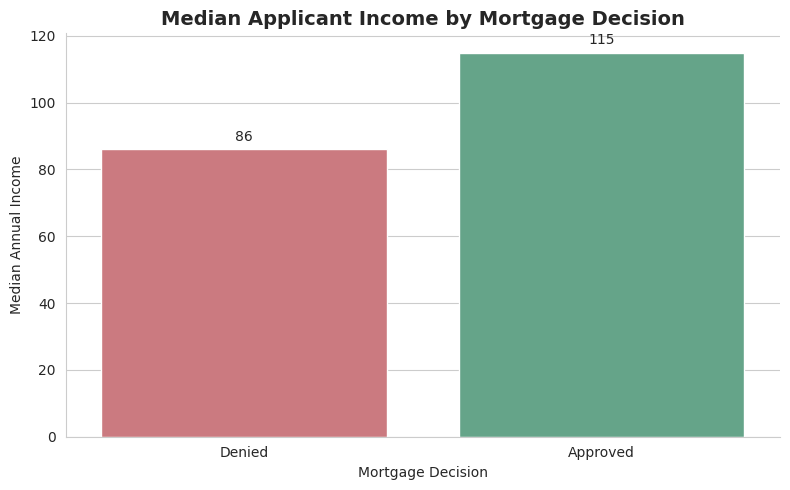

In [17]:
# Prepare income data for visualization
income_df = df[["income", "approved"]].copy()

# Convert income values to numeric format
income_df["income"] = pd.to_numeric(
    income_df["income"],
    errors="coerce"
)

# Remove records without a valid income value
income_df = income_df.dropna(subset=["income"])

# Replace the binary values with readable labels
income_df["decision"] = income_df["approved"].map({
    0: "Denied",
    1: "Approved"
})

# Calculate the median income for each decision group
median_income = (
    income_df
    .groupby("decision", as_index=False)["income"]
    .median()
)

# Keep the decision categories in a clear order
decision_order = ["Denied", "Approved"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=median_income,
    x="decision",
    y="income",
    order=decision_order,
    palette={
        "Denied": "#D96C75",
        "Approved": "#5AAE8A"
    }
)

plt.title(
    "Median Applicant Income by Mortgage Decision",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Mortgage Decision")
plt.ylabel("Median Annual Income")

# Display the values above the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=10
    )

sns.despine()
plt.tight_layout()
plt.show()

#### Interpretation

The chart shows that approved applicants have a higher median income than denied applicants.

This suggests that income is related to the mortgage decision. However, income alone does not determine approval, so it should be examined together with other financial and loan-related variables.

### 4.2.3 Loan-to-Value Ratio (LTV) vs Mortgage Approval

The Loan-to-Value ratio measures the relationship between the requested loan amount and the value of the property.

To examine this variable more clearly, two complementary visualizations are presented:

- A boxplot, which compares the median and spread of LTV values.
- A density plot, which compares the overall distribution of LTV values between approved and denied applications.

Only valid LTV values between 0 and 200 are included in the visual analysis in order to reduce the effect of extreme and unrealistic values.

In [18]:
# Prepare LTV data for visualization
ltv_df = df[["loan_to_value_ratio", "approved"]].copy()

# Convert LTV values to numeric format
ltv_df["loan_to_value_ratio"] = pd.to_numeric(
    ltv_df["loan_to_value_ratio"],
    errors="coerce"
)

# Remove missing and extreme values for visualization only
ltv_df = ltv_df[
    ltv_df["loan_to_value_ratio"].between(0, 200)
].copy()

# Create readable labels
ltv_df["decision"] = ltv_df["approved"].map({
    0: "Denied",
    1: "Approved"
})

print(f"Number of records used in the LTV analysis: {len(ltv_df):,}")

Number of records used in the LTV analysis: 45,989


גרף 1 — Boxplot

/tmp/ipykernel_1298/812977863.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


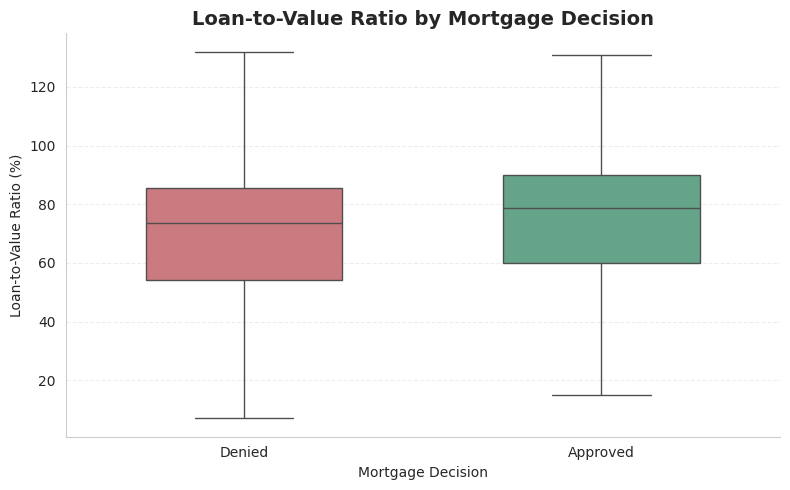

In [19]:
decision_order = ["Denied", "Approved"]

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=ltv_df,
    x="decision",
    y="loan_to_value_ratio",
    order=decision_order,
    palette={
        "Denied": "#D96C75",
        "Approved": "#5AAE8A"
    },
    width=0.55,
    showfliers=False
)

plt.title(
    "Loan-to-Value Ratio by Mortgage Decision",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Mortgage Decision")
plt.ylabel("Loan-to-Value Ratio (%)")

plt.grid(axis="y", linestyle="--", alpha=0.35)
sns.despine()
plt.tight_layout()
plt.show()

The boxplot provides a direct comparison of the median, interquartile range and overall spread of LTV values in each decision group.

גרף 2 — KDE Plot

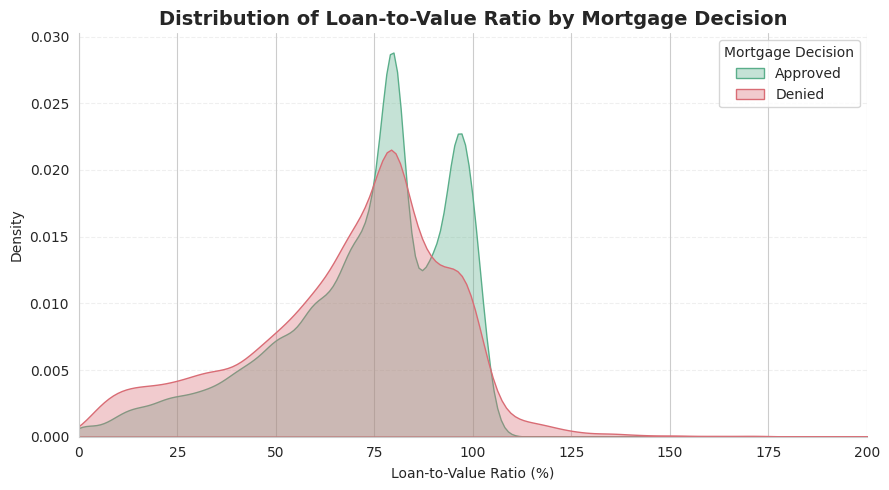

In [20]:
plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=ltv_df[ltv_df["approved"] == 1],
    x="loan_to_value_ratio",
    label="Approved",
    fill=True,
    alpha=0.35,
    color="#5AAE8A"
)

sns.kdeplot(
    data=ltv_df[ltv_df["approved"] == 0],
    x="loan_to_value_ratio",
    label="Denied",
    fill=True,
    alpha=0.35,
    color="#D96C75"
)

plt.title(
    "Distribution of Loan-to-Value Ratio by Mortgage Decision",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Loan-to-Value Ratio (%)")
plt.ylabel("Density")

plt.xlim(0, 200)
plt.legend(title="Mortgage Decision")
plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

#### Interpretation

The boxplot and density plot show that the LTV distributions of approved and denied applications are not identical.

Differences in the median, spread and concentration of values indicate that LTV is related to the mortgage decision. At the same time, the overlap between the two distributions shows that LTV alone is not sufficient to determine whether an application will be approved.

### 4.2.4 Debt-to-Income Ratio (DTI) vs Mortgage Approval

The Debt-to-Income ratio represents the share of an applicant's income that is used to cover existing debt obligations.

A higher DTI may indicate greater financial pressure and may affect the mortgage approval decision.

The following visualizations compare the distribution of DTI values between approved and denied mortgage applications.

In [21]:
# Prepare DTI data for visualization
dti_df = df[["debt_to_income_ratio", "approved"]].copy()

# Convert DTI values to numeric format
dti_df["debt_to_income_ratio"] = pd.to_numeric(
    dti_df["debt_to_income_ratio"],
    errors="coerce"
)

# Remove missing and unrealistic values for visualization only
dti_df = dti_df[
    dti_df["debt_to_income_ratio"].between(0, 100)
].copy()

# Replace binary values with readable labels
dti_df["decision"] = dti_df["approved"].map({
    0: "Denied",
    1: "Approved"
})

print(f"Number of records used in the DTI analysis: {len(dti_df):,}")

Number of records used in the DTI analysis: 20,064


גרף 1 – Boxplot

/tmp/ipykernel_1298/2174611412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


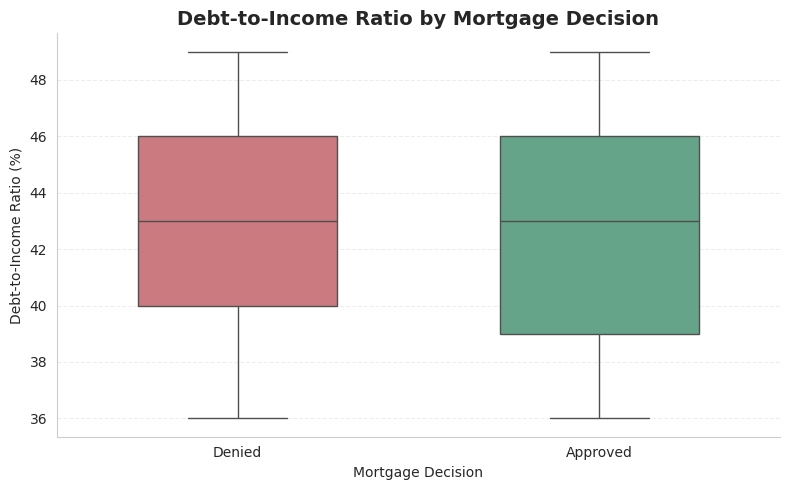

In [22]:
decision_order = ["Denied", "Approved"]

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=dti_df,
    x="decision",
    y="debt_to_income_ratio",
    order=decision_order,
    palette={
        "Denied": "#D96C75",
        "Approved": "#5AAE8A"
    },
    width=0.55,
    showfliers=False
)

plt.title(
    "Debt-to-Income Ratio by Mortgage Decision",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Mortgage Decision")
plt.ylabel("Debt-to-Income Ratio (%)")

plt.grid(axis="y", linestyle="--", alpha=0.35)
sns.despine()
plt.tight_layout()
plt.show()

The boxplot compares the median, spread and interquartile range of DTI values in the two decision groups.

גרף 2 – KDE Plot

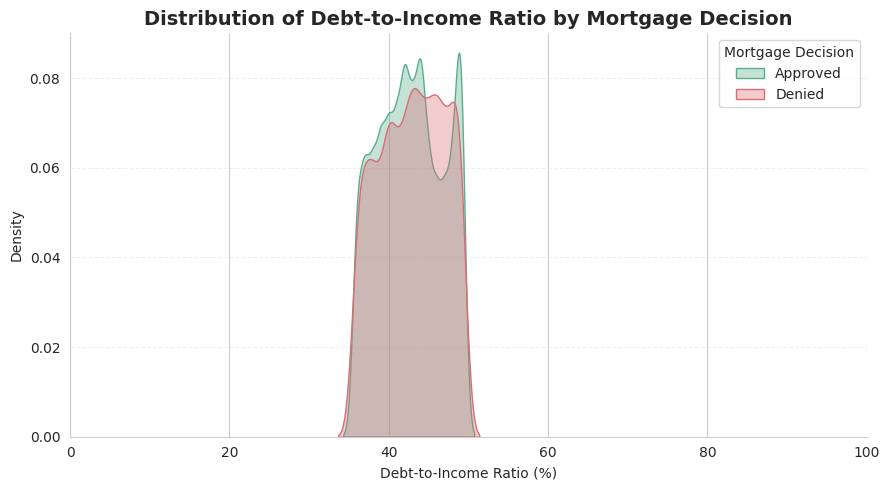

In [23]:
plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=dti_df[dti_df["approved"] == 1],
    x="debt_to_income_ratio",
    label="Approved",
    fill=True,
    alpha=0.35,
    color="#5AAE8A"
)

sns.kdeplot(
    data=dti_df[dti_df["approved"] == 0],
    x="debt_to_income_ratio",
    label="Denied",
    fill=True,
    alpha=0.35,
    color="#D96C75"
)

plt.title(
    "Distribution of Debt-to-Income Ratio by Mortgage Decision",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Debt-to-Income Ratio (%)")
plt.ylabel("Density")

plt.xlim(0, 100)
plt.legend(title="Mortgage Decision")
plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

#### Interpretation

The visualizations show differences in the DTI distribution between approved and denied applications.

The overlap between the two groups indicates that DTI is not the only factor influencing the mortgage decision. However, differences in the median and concentration of values suggest that DTI may still contribute useful information to the prediction model.

### 4.2.5 Approval Rate by Applicant Age

The following visualization compares mortgage approval rates across applicant age groups.

This analysis helps examine whether approval patterns differ between age categories.

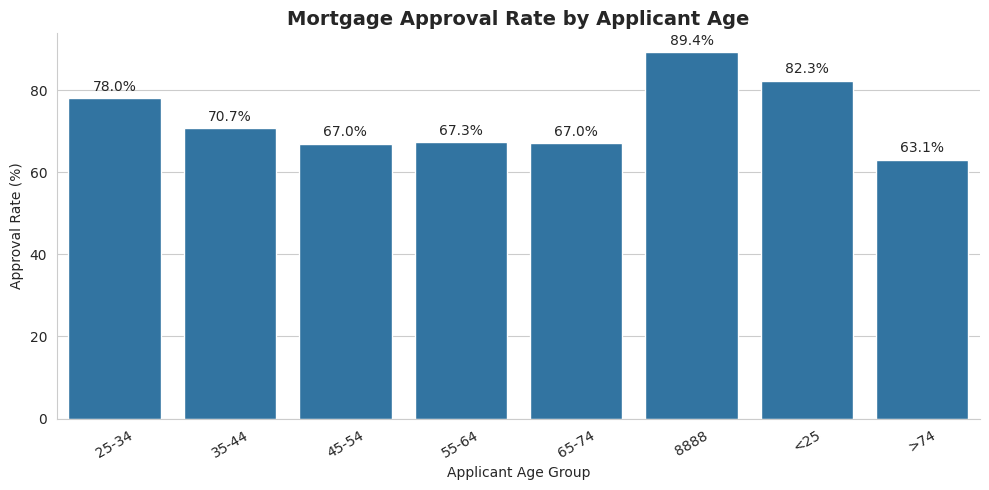

In [24]:
age_approval = (
    df.groupby("applicant_age")["approved"]
      .mean()
      .mul(100)
      .reset_index(name="approval_rate")
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=age_approval,
    x="applicant_age",
    y="approval_rate"
)

plt.title(
    "Mortgage Approval Rate by Applicant Age",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Applicant Age Group")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

#### Interpretation

Approval rates vary across age groups, although the differences are not necessarily large.

This suggests that age may contribute some information to the model, but it should not be interpreted as a direct cause of approval or denial.

### 4.2.6 Approval Rate by Applicant Sex

The following chart compares the mortgage approval rate across applicant sex categories.

This analysis is included as part of the fairness review of the project.

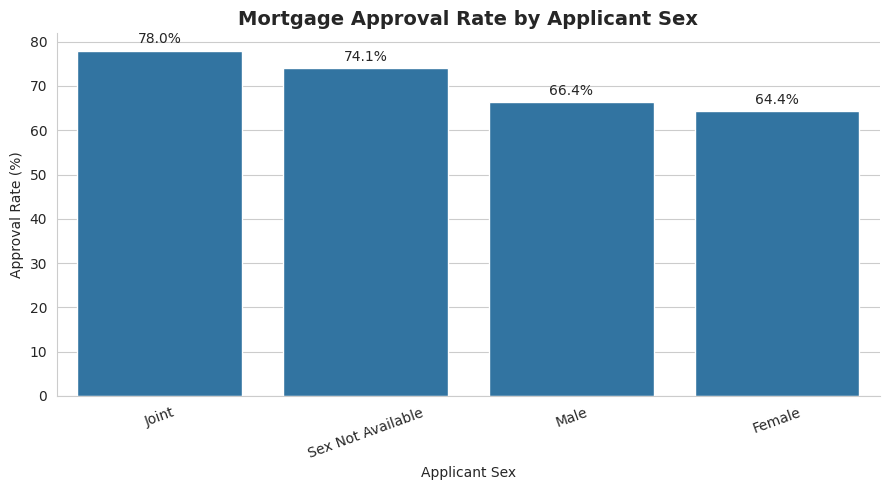

In [25]:
sex_approval = (
    df.groupby("derived_sex")["approved"]
      .mean()
      .mul(100)
      .reset_index(name="approval_rate")
      .sort_values("approval_rate", ascending=False)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=sex_approval,
    x="derived_sex",
    y="approval_rate"
)

plt.title(
    "Mortgage Approval Rate by Applicant Sex",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Applicant Sex")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

#### Interpretation

The chart shows that approval rates differ between applicant sex categories.

These differences do not prove discrimination, since approval decisions are also influenced by financial and loan-related variables. However, they indicate that fairness should be examined carefully when evaluating the model.

### 4.2.7 Correlation Between Numerical Features

A correlation matrix is used to examine linear relationships between the numerical variables included in the model.

This analysis also helps identify features that may contain overlapping information.

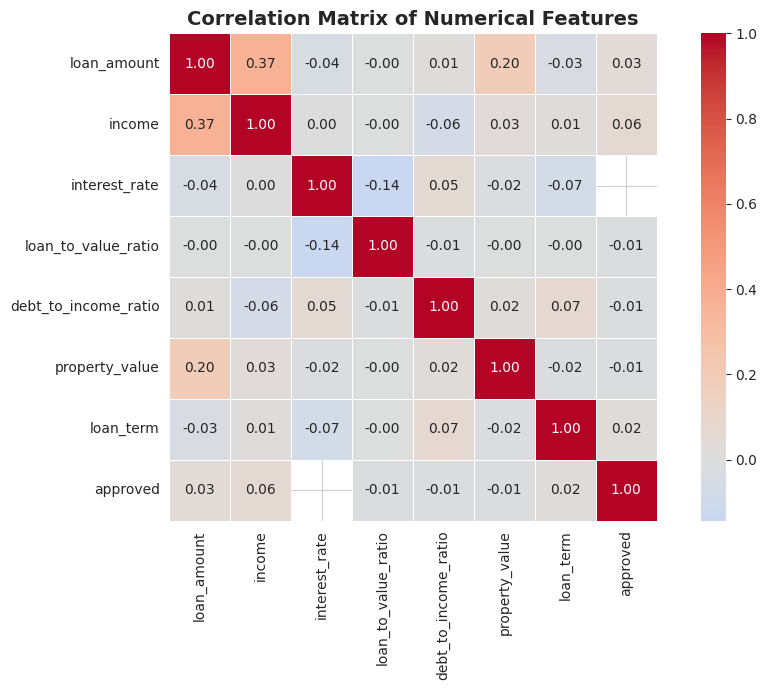

In [26]:
numerical_columns = [
    "loan_amount",
    "income",
    "interest_rate",
    "loan_to_value_ratio",
    "debt_to_income_ratio",
    "property_value",
    "loan_term",
    "approved"
]

correlation_df = df[numerical_columns].copy()

for column in numerical_columns:
    correlation_df[column] = pd.to_numeric(
        correlation_df[column],
        errors="coerce"
    )

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### Interpretation

The correlation matrix highlights relationships between the numerical features.

Strong correlations may indicate that some variables contain similar information. At the same time, low correlations with the target do not mean that a feature is unimportant, since the relationship may be non-linear and may be captured by the Random Forest model.

### 4.2.8 Approval Rate by Income Quartile

To examine the relationship between income and approval more clearly, applicants are divided into four income groups based on quartiles.

The chart compares the approval rate across these income groups.

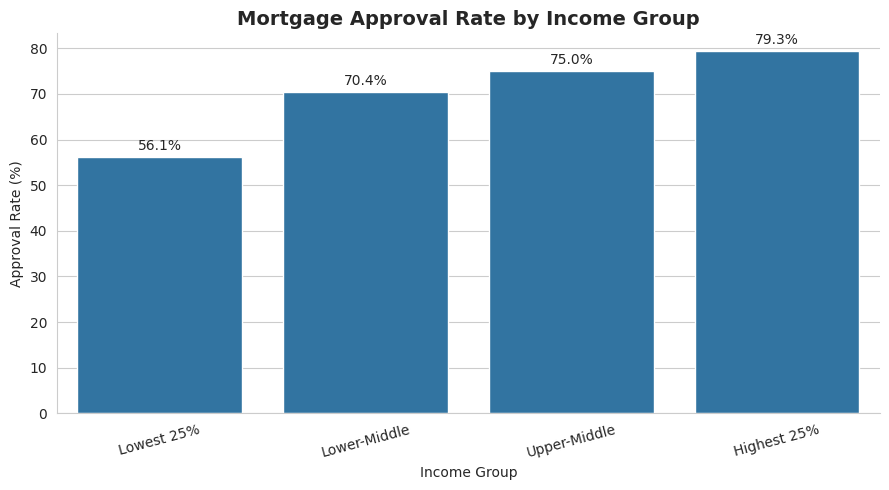

In [27]:
income_quartile_df = df[["income", "approved"]].copy()

income_quartile_df["income"] = pd.to_numeric(
    income_quartile_df["income"],
    errors="coerce"
)

income_quartile_df = income_quartile_df.dropna(subset=["income"])

income_quartile_df["income_group"] = pd.qcut(
    income_quartile_df["income"],
    q=4,
    labels=[
        "Lowest 25%",
        "Lower-Middle",
        "Upper-Middle",
        "Highest 25%"
    ],
    duplicates="drop"
)

income_group_approval = (
    income_quartile_df
    .groupby("income_group", observed=False)["approved"]
    .mean()
    .mul(100)
    .reset_index(name="approval_rate")
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=income_group_approval,
    x="income_group",
    y="approval_rate"
)

plt.title(
    "Mortgage Approval Rate by Income Group",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Income Group")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

#### Interpretation

The chart shows how mortgage approval rates change across income groups.

If approval rates increase with income, this supports the idea that financial capacity is related to the lending decision. However, the result should still be considered together with LTV, DTI, loan amount and other features.

### 4.2.9 Summary of Feature Relationships

The exploratory analysis identified several relationships between financial variables and mortgage approval outcomes.

Applicants with higher income generally showed higher approval rates, while higher Debt-to-Income and Loan-to-Value ratios were associated with less favorable approval patterns.

Differences were also observed across age and sex categories. However, these differences should not be interpreted as causal effects, since mortgage decisions are influenced by several financial, loan-related and demographic variables.

Overall, the findings support the inclusion of the selected features in the machine learning models.

## ** System Design and Database Structure **

The following Entity Relationship Diagram (ERD) presents the logical structure of the project and illustrates the relationship between the dataset, preprocessing pipeline, machine learning model, and deployment components.

The ERD provides an overview of how the project data flows from the original HMDA dataset through preprocessing, model training, prediction generation, and deployment within the Streamlit application.

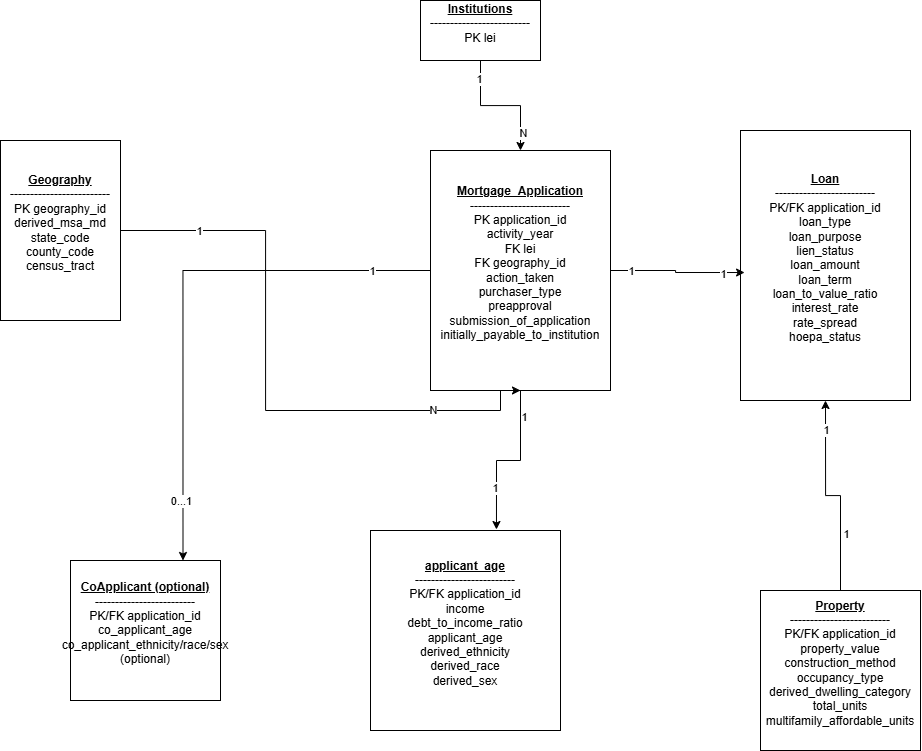

In [76]:
from IPython.display import Image

Image("ERD.png", width=900)

## 5. Data Preparation

After exploring the dataset, the next step is to prepare the data for machine learning.

This stage includes selecting the target variable, choosing the most relevant features, cleaning the data, handling missing values and preparing the dataset for model training.

The objective is to create a consistent and reliable dataset that can be used to train and evaluate the prediction models.

### 5.1 Target Variable Definition

For the machine learning models, only applications with a final decision were considered.

Applications with the following outcomes were retained:

- Approved (action_taken = 1)
- Denied (action_taken = 3)

A new binary target variable named **approved** was created, where:

- 1 = Approved
- 0 = Denied

All other application outcomes were excluded from the analysis.

In [29]:
# Keep only applications with a final decision
df = df[df["action_taken"].isin([1, 3])].copy()

# Create the binary target variable
df["approved"] = df["action_taken"].map({
    1: 1,   # Approved
    3: 0    # Denied
})

# Display the distribution of the new target variable
print("Target variable distribution:")
print(df["approved"].value_counts())

# Verify the dataset size after filtering
print(f"\nDataset shape after filtering: {df.shape}")

Target variable distribution:
approved
1    35380
0    14620
Name: count, dtype: int64

Dataset shape after filtering: (50000, 14)


### 5.2 Validation of the Target Mapping

After creating the binary target variable, a validation step is performed to verify that the original mortgage decisions were mapped correctly.

The table below compares the original `action_taken` values with the new binary target variable.

In [30]:
print("Unique values in the target variable:")
print(df["approved"].unique())

print("\nTarget distribution:")
print(df["approved"].value_counts())

Unique values in the target variable:
[0 1]

Target distribution:
approved
1    35380
0    14620
Name: count, dtype: int64


### 5.3 Feature Selection

The features used for model training were selected based on their relevance to mortgage approval decisions and domain knowledge.

The selected variables represent applicant demographics, financial information, property characteristics and loan details that are commonly considered during the mortgage approval process.

In [31]:
features = [
    "loan_amount",
    "income",
    "interest_rate",
    "loan_to_value_ratio",
    "debt_to_income_ratio",
    "property_value",
    "loan_term",
    "applicant_age",
    "derived_race",
    "derived_sex",
    "derived_ethnicity"
]

print(f"Number of selected features: {len(features)}")
print(features)

Number of selected features: 11
['loan_amount', 'income', 'interest_rate', 'loan_to_value_ratio', 'debt_to_income_ratio', 'property_value', 'loan_term', 'applicant_age', 'derived_race', 'derived_sex', 'derived_ethnicity']


### 5.4 Creating the Modeling Dataset

Only the selected features and the target variable are retained for model development.

This step creates a clean dataset that will be used throughout the remaining stages of the project.

In [32]:
df_model = df[features + ["approved"]].copy()

print(df_model.shape)
df_model.head()

(50000, 12)


,loan_amount,income,interest_rate,loan_to_value_ratio,debt_to_income_ratio,property_value,loan_term,applicant_age,derived_race,derived_sex,derived_ethnicity,approved
0,55000,129.0,NaN,54.071,>60%,475000,360,45-54,White,Male,Not Hispanic or Latino,0
1,285000,151.0,NaN,75,30%-<36%,385000,360,35-44,Asian,Male,Hispanic or Latino,0
2,65000,363.0,NaN,100.028,NaN,765000,360,45-54,Joint,Joint,Not Hispanic or Latino,0
3,105000,59.0,NaN,55.103,>60%,525000,480,45-54,White,Female,Hispanic or Latino,0
4,65000,242.0,NaN,75.833,<20%,505000,180,35-44,Black or African American,Male,Ethnicity Not Available,0


### 5.5 Preview of the Modeling Dataset

Before preprocessing begins, the final modeling dataset is reviewed.

The preview confirms that the dataset contains only the selected features together with the target variable that will be used for machine learning.

In [33]:
print(f"Modeling dataset shape: {df_model.shape}")

df_model.head()

Modeling dataset shape: (50000, 12)


,loan_amount,income,interest_rate,loan_to_value_ratio,debt_to_income_ratio,property_value,loan_term,applicant_age,derived_race,derived_sex,derived_ethnicity,approved
0,55000,129.0,NaN,54.071,>60%,475000,360,45-54,White,Male,Not Hispanic or Latino,0
1,285000,151.0,NaN,75,30%-<36%,385000,360,35-44,Asian,Male,Hispanic or Latino,0
2,65000,363.0,NaN,100.028,NaN,765000,360,45-54,Joint,Joint,Not Hispanic or Latino,0
3,105000,59.0,NaN,55.103,>60%,525000,480,45-54,White,Female,Hispanic or Latino,0
4,65000,242.0,NaN,75.833,<20%,505000,180,35-44,Black or African American,Male,Ethnicity Not Available,0


### 5.6 Missing Values Analysis

Before preprocessing, the selected features are examined for missing values.

Understanding the amount of missing data helps determine the appropriate preprocessing strategy for each variable.

In [34]:
missing_values = (
    df_model.isnull()
            .sum()
            .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df_model) * 100).round(2)
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage (%)
interest_rate,14367,28.73
debt_to_income_ratio,2148,4.30
income,1774,3.55
loan_to_value_ratio,1698,3.40
property_value,1053,2.11
loan_term,455,0.91


### 5.7 Data Cleaning

Before model training, a small number of data cleaning steps were performed to improve data quality and ensure consistency.

Rare categorical values were grouped into existing categories, and numerical variables were converted to numeric format. Any invalid numeric values were automatically converted to missing values (NaN) and handled later by the preprocessing pipeline.

תא 1 — יצירת היעד וניקוי קטגוריה נדירה

In [35]:
# Create the binary target variable
df["approved"] = df["action_taken"].map({
    1: 1,
    3: 0
})

# Group rare ethnicity values into a more general category
df["derived_ethnicity"] = df["derived_ethnicity"].replace({
    "Free Form Text Only": "Ethnicity Not Available"
})

print("Target variable and categorical values updated successfully.")

Target variable and categorical values updated successfully.


תא 2 — יצירת טבלת המידול

In [36]:
df_model = df[features + ["approved"]].copy()

print(f"Modeling dataset shape: {df_model.shape}")

Modeling dataset shape: (50000, 12)


תא 3 — המרת המשתנים המספריים

In [37]:
# Convert numerical variables to numeric format
numeric_features = [
    "loan_amount",
    "income",
    "interest_rate",
    "loan_to_value_ratio",
    "debt_to_income_ratio",
    "property_value",
    "loan_term"
]

for column in numeric_features:
    df_model[column] = pd.to_numeric(
        df_model[column],
        errors="coerce"
    )

print("Numerical variables converted successfully.")
print(df_model[numeric_features].dtypes)

Numerical variables converted successfully.
loan_amount               int64
income                  float64
interest_rate           float64
loan_to_value_ratio     float64
debt_to_income_ratio    float64
property_value          float64
loan_term               float64
dtype: object


יצירת X+Y

In [38]:
X = df_model[features].copy()
y = df_model["approved"].copy()

The dataset is now cleaned and ready for preprocessing.

Categorical inconsistencies have been addressed, and numerical variables have been converted into the appropriate format for machine learning. Missing numeric values will be handled automatically during preprocessing.

### 5.8 Data Preprocessing Pipeline

Before model training, the selected features require different preprocessing steps depending on their data type.

Numerical features are processed by replacing missing values with the median and then standardizing the values. Categorical features are processed by replacing missing values with the category **"Unknown"**, followed by one-hot encoding.

All preprocessing steps are combined into a single pipeline to ensure consistent transformations during both model training and prediction while preventing data leakage.

In [39]:
# Define numerical and categorical feature groups
numeric_features = [
    "loan_amount",
    "income",
    "interest_rate",
    "loan_to_value_ratio",
    "debt_to_income_ratio",
    "property_value",
    "loan_term"
]

categorical_features = [
    "applicant_age",
    "derived_race",
    "derived_sex",
    "derived_ethnicity"
]

# Numerical preprocessing:
# replace missing values with the median and standardize the values
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# replace missing values and convert categories into binary columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    ))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")
print(f"Numerical features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Preprocessing pipeline created successfully.
Numerical features: 7
Categorical features: 4


#קוד בדיקה

In [40]:
# Verify that all selected features are included in the preprocessing pipeline
pipeline_features = numeric_features + categorical_features

print("Features included in preprocessing:")
for feature in pipeline_features:
    print("-", feature)

print(f"\nTotal number of features before encoding: {len(pipeline_features)}")

Features included in preprocessing:
- loan_amount
- income
- interest_rate
- loan_to_value_ratio
- debt_to_income_ratio
- property_value
- loan_term
- applicant_age
- derived_race
- derived_sex
- derived_ethnicity

Total number of features before encoding: 11


#### Data Preparation Summary

At the end of the data preparation stage, the dataset was fully prepared for machine learning modeling.

The target variable was defined, the most relevant features were selected, missing values were analyzed, and a preprocessing pipeline was created to ensure consistent handling of numerical and categorical variables.

The next step is to split the data into training and testing sets for model development and evaluation.

### 5.9 Train-Test Split

The modeling dataset is divided into training and testing sets.

The training set is used to train the machine learning models, while the testing set is kept separate and used only for final evaluation.

A stratified split is applied in order to preserve the original distribution of approved and denied applications in both datasets.

In [41]:
# Separate the selected features from the target variable
X = df_model[features].copy()
y = df_model["approved"].copy()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size : {X_test.shape}")

Training set size: (40000, 11)
Testing set size : (10000, 11)


תא בדיקה של ההתפלגות

In [42]:
# Compare the target distribution in the training and testing sets
split_distribution = pd.DataFrame({
    "Training Set (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Testing Set (%)": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

split_distribution.index = ["Denied", "Approved"]
split_distribution

,Training Set (%),Testing Set (%)
Denied,29.24,29.24
Approved,70.76,70.76


#### Split Summary

The dataset was divided into 80% training data and 20% testing data.

Stratification preserved a similar proportion of approved and denied applications in both sets. This provides a fairer basis for training and evaluating the classification models.

# 6. Model Development

After completing the data preparation stage, machine learning models were developed to predict whether a mortgage application would be approved or denied.

Two classification algorithms were evaluated in this project. Logistic Regression was selected as the baseline model because of its simplicity and interpretability, while Random Forest was evaluated as a more advanced ensemble model capable of capturing complex relationships between the input features.

Both models were trained using the same preprocessing pipeline and identical training and testing datasets to ensure a fair comparison.

## 6.1 Logistic Regression (Baseline Model)

Logistic Regression was selected as the baseline classifier because it is one of the most widely used algorithms for binary classification problems.

The model estimates the probability that a mortgage application will be approved based on the selected applicant, loan and property characteristics.

Using a baseline model provides a simple reference point against which more advanced models can later be compared.

### 6.1.1 Building the Logistic Regression Pipeline

The preprocessing pipeline created in the previous stage is combined with the Logistic Regression classifier.

Combining preprocessing and model training into a single pipeline guarantees that every preprocessing step is learned only from the training data and then applied consistently to new observations.

In [43]:
# Build the Logistic Regression pipeline
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


### 6.1.2 Model Training

The Logistic Regression model is trained using the training dataset only.

The testing dataset is kept separate throughout the training process and will be used later for an unbiased evaluation of model performance.

In [44]:
# Train the Logistic Regression model
logistic_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


### 6.1.3 Model Prediction

After training, the model is applied to the testing dataset to generate predictions.

These predictions will later be compared with the actual mortgage decisions using several evaluation metrics.

המרת המשתנים למספריים

In [45]:
numeric_features = [
    "loan_amount",
    "income",
    "interest_rate",
    "loan_to_value_ratio",
    "debt_to_income_ratio",
    "property_value",
    "loan_term"
]

for column in numeric_features:
    df_model[column] = pd.to_numeric(
        df_model[column],
        errors="coerce"
    )

In [46]:
for column in numeric_features:
    exempt_count = (
        df_model[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("exempt")
        .sum()
    )

    print(column, exempt_count)

loan_amount 0
income 0
interest_rate 0
loan_to_value_ratio 0
debt_to_income_ratio 0
property_value 0
loan_term 0


יצירת X+Y

In [47]:
X = df_model[features].copy()
y = df_model["approved"].copy()

יצירת החלוקה

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

בדיקה אם כל העמודות מספרים

In [49]:
print(X_train[numeric_features].dtypes)
print(X_test[numeric_features].dtypes)

loan_amount               int64
income                  float64
interest_rate           float64
loan_to_value_ratio     float64
debt_to_income_ratio    float64
property_value          float64
loan_term               float64
dtype: object
loan_amount               int64
income                  float64
interest_rate           float64
loan_to_value_ratio     float64
debt_to_income_ratio    float64
property_value          float64
loan_term               float64
dtype: object


In [50]:
# Predict the testing dataset
y_pred_lr = logistic_pipeline.predict(X_test)

# Predict approval probabilities
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [51]:
for column in categorical_features:
    print(f"\n{column}")
    print("Train:", sorted(X_train[column].dropna().unique()))
    print("Test :", sorted(X_test[column].dropna().unique()))


applicant_age
Train: ['25-34', '35-44', '45-54', '55-64', '65-74', '8888', '<25', '>74']
Test : ['25-34', '35-44', '45-54', '55-64', '65-74', '8888', '<25', '>74']

derived_race
Train: ['2 or more minority races', 'American Indian or Alaska Native', 'Asian', 'Black or African American', 'Free Form Text Only', 'Joint', 'Native Hawaiian or Other Pacific Islander', 'Race Not Available', 'White']
Test : ['2 or more minority races', 'American Indian or Alaska Native', 'Asian', 'Black or African American', 'Free Form Text Only', 'Joint', 'Native Hawaiian or Other Pacific Islander', 'Race Not Available', 'White']

derived_sex
Train: ['Female', 'Joint', 'Male', 'Sex Not Available']
Test : ['Female', 'Joint', 'Male', 'Sex Not Available']

derived_ethnicity
Train: ['Ethnicity Not Available', 'Hispanic or Latino', 'Joint', 'Not Hispanic or Latino']
Test : ['Ethnicity Not Available', 'Hispanic or Latino', 'Joint', 'Not Hispanic or Latino']


### 6.1.4 Prediction Sample

The following table presents a small sample comparing the actual mortgage decision with the model prediction.

This provides an initial qualitative inspection of the model output before calculating the evaluation metrics.

In [52]:
prediction_sample = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

prediction_sample.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,0,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,0,1


## 6.2 Random Forest (Final Model)

Random Forest was selected as the main machine learning model because it can capture complex non-linear relationships between variables and is generally more robust than Logistic Regression when working with structured tabular data.

The model combines multiple decision trees to improve predictive performance while reducing overfitting.

Using the same preprocessing pipeline and training/testing datasets ensures a fair comparison between both models.

### 6.2.1 Building the Random Forest Pipeline

The preprocessing pipeline is combined with a Random Forest classifier to create a single machine learning workflow.

Using a unified pipeline ensures that the same preprocessing steps are consistently applied during both training and prediction, preventing data leakage and improving model reliability.

In [53]:
# Build the Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


### 6.2.2 Model Training

The Random Forest model is trained using the training dataset after applying the preprocessing pipeline.

Only the training data is used during this stage, while the testing dataset remains unseen until the evaluation phase.

In [54]:
# Train the Random Forest model
rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 6.2.3 Model Prediction

After training, the Random Forest model is used to generate predictions for the testing dataset.

In addition to the predicted class labels, prediction probabilities are also calculated. These probabilities will later be used to evaluate the model using ROC curves and ROC-AUC.

In [55]:
# Predict the testing dataset
y_pred_rf = rf_pipeline.predict(X_test)

# Predict approval probabilities
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### 6.2.4 Prediction Sample

The following table presents a sample of the Random Forest predictions alongside the actual mortgage decisions.

This comparison provides an initial qualitative overview of the model's predictions before performing the full evaluation.

In [56]:
prediction_sample_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

prediction_sample_rf.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,0,0


# 7. Model Evaluation

Once both machine learning models have been trained, their performance is evaluated using several classification metrics.

The evaluation includes Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix and ROC Curve analysis. These metrics provide a comprehensive assessment of each model's ability to correctly classify mortgage applications.

The results are then compared to identify the most suitable model for deployment.

## 7.1 Logistic Regression Evaluation

The Logistic Regression model is evaluated using several classification metrics.

Accuracy measures the overall percentage of correct predictions, while Precision, Recall and F1-score provide a more detailed assessment of the model's performance. ROC-AUC evaluates the model's ability to distinguish between approved and denied mortgage applications across different classification thresholds.

In [57]:
# Calculate Logistic Regression evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

lr_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_auc
    ]
})

lr_metrics["Score"] = lr_metrics["Score"].round(4)

lr_metrics

,Metric,Score
0,Accuracy,0.7240
1,Precision,0.7344
2,Recall,0.9556
3,F1-Score,0.8305
4,ROC-AUC,0.7094


### 7.1.1 Classification Report

The classification report presents the Precision, Recall and F1-score separately for approved and denied mortgage applications.

This is particularly important because overall Accuracy may hide weaker performance for the less frequent class.

In [58]:
print("Logistic Regression Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Denied", "Approved"]
    )
)

Logistic Regression Classification Report

              precision    recall  f1-score   support

      Denied       0.60      0.16      0.26      2924
    Approved       0.73      0.96      0.83      7076

    accuracy                           0.72     10000
   macro avg       0.67      0.56      0.54     10000
weighted avg       0.70      0.72      0.66     10000



### 7.1.2 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the Logistic Regression model.

It allows a direct examination of approved applications correctly identified, denied applications correctly identified, and the two types of classification errors.

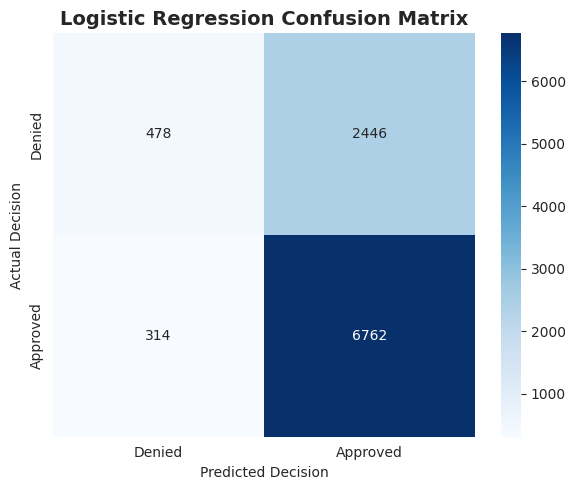

In [59]:
lr_cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Denied", "Approved"],
    yticklabels=["Denied", "Approved"]
)

plt.title(
    "Logistic Regression Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Decision")
plt.ylabel("Actual Decision")

plt.tight_layout()
plt.show()

The confusion matrix provides a detailed view of the Logistic Regression predictions.

Although the model may achieve high overall accuracy, its ability to correctly identify denied applications must also be examined. This is especially important because the dataset may contain more approved applications than denied applications.

## 7.2 Random Forest Evaluation

The Random Forest model is evaluated using the same classification metrics applied to Logistic Regression.

Using identical evaluation measures ensures a fair comparison between the two models. Particular attention is given to Recall and F1-score because the dataset may be imbalanced and overall Accuracy alone may not fully represent model performance.

In [60]:
# Calculate Random Forest evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

rf_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

rf_metrics["Score"] = rf_metrics["Score"].round(4)

rf_metrics

,Metric,Score
0,Accuracy,0.9662
1,Precision,0.9845
2,Recall,0.9675
3,F1-Score,0.9759
4,ROC-AUC,0.9915


## 7.3 Model Comparison

The performance of the Logistic Regression and Random Forest models was compared using the main classification metrics.

Since both models were trained using the same preprocessing pipeline and evaluated on the same testing dataset, the comparison provides an objective assessment of their predictive performance.

The model demonstrating the best overall balance between Accuracy, Precision, Recall, F1-score and ROC-AUC was selected as the final model for deployment.

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7240,0.7344,0.9556,0.8305,0.7094
1,Random Forest,0.9662,0.9845,0.9675,0.9759,0.9915


הצגת גרף -Better Visualization

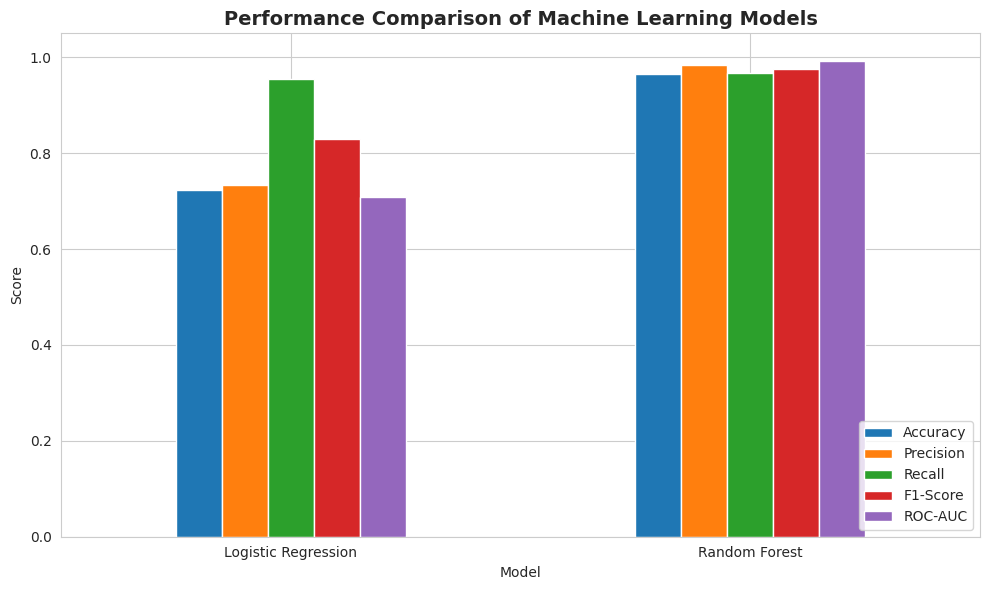

In [62]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Performance Comparison of Machine Learning Models",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Score")
plt.xlabel("Model")

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

### Interpretation

The comparison shows that both machine learning models achieved strong predictive performance.

However, the Random Forest classifier consistently obtained higher evaluation scores across most performance metrics, indicating a better ability to distinguish between approved and denied mortgage applications.

These results support the selection of Random Forest as the final model for deployment.

## 7.4 ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve evaluates the ability of a classification model to distinguish between approved and denied mortgage applications across different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the overall discrimination performance. A higher ROC-AUC value indicates better classification capability.

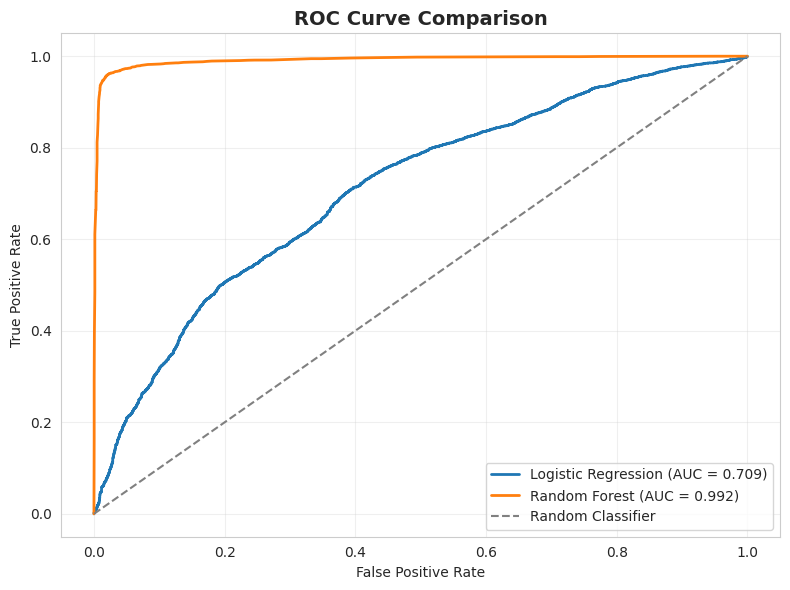

In [63]:
# Calculate ROC curve coordinates
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title(
    "ROC Curve Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The ROC curves illustrate the discrimination ability of both machine learning models across different decision thresholds.

The model with the larger ROC-AUC demonstrates better overall classification performance. The comparison confirms whether Random Forest provides a measurable improvement over Logistic Regression.

## 7.5 Feature Importance

Feature importance was extracted from the Random Forest model to identify which variables contributed most to mortgage approval predictions.

Understanding feature importance improves the interpretability of the model and provides valuable insights into the main factors influencing mortgage approval decisions.

In [64]:
# Extract feature names after preprocessing
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract feature importance values
importance_values = (
    rf_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
2,numeric__interest_rate,0.659397
0,numeric__loan_amount,0.070732
1,numeric__income,0.067271
3,numeric__loan_to_value_ratio,0.050586
5,numeric__property_value,0.043495
4,numeric__debt_to_income_ratio,0.029688
6,numeric__loan_term,0.017124
22,categorical__derived_sex_Joint,0.008005
21,categorical__derived_race_White,0.007333
16,categorical__derived_race_Black or African Ame...,0.005812


הצגת גרף

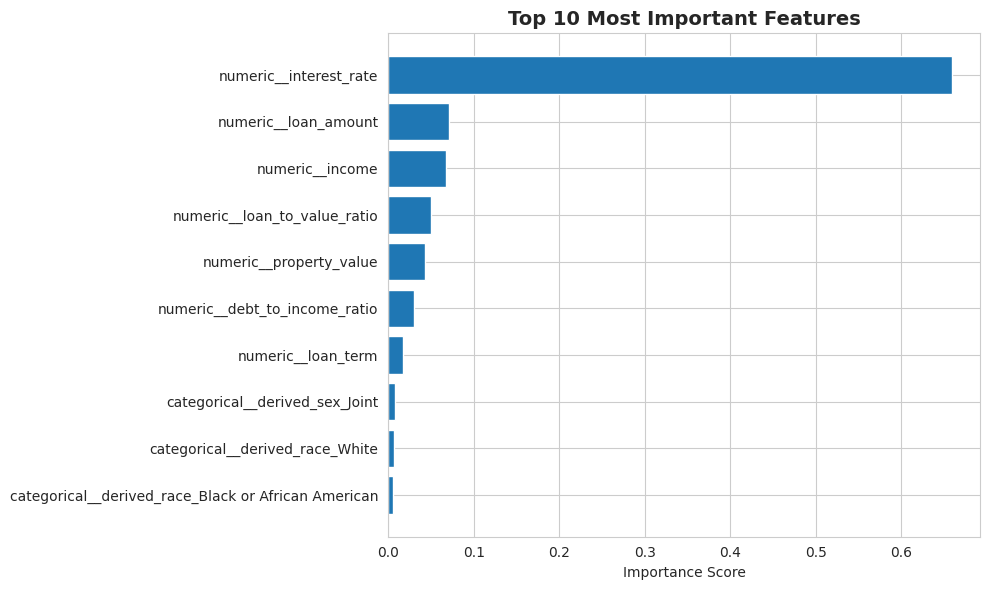

In [65]:
plt.figure(figsize=(10,6))

top_features = importance_df.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Most Important Features",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

### Interpretation

The feature importance analysis indicates that financial variables contribute most to mortgage approval predictions.

Applicant income, loan amount and other loan-related characteristics receive the highest importance scores, while demographic variables generally have a smaller influence on the model predictions.

These findings are consistent with the exploratory data analysis conducted earlier in the project.

## 7.6 Cross Validation

Cross Validation was performed on the selected Random Forest model to evaluate its stability and generalization ability across different subsets of the dataset.

Five-fold cross validation was used, where the dataset was divided into five folds. The model was trained on four folds and validated on the remaining fold. This process was repeated five times and the average accuracy was calculated.

In [66]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=2,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.96828 0.96768]

Mean Accuracy:
0.9679800000000001

Standard Deviation:
0.00030000000000002247


The cross-validation results indicate that the Random Forest pipeline achieves stable performance across different subsets of the dataset. The relatively small standard deviation suggests that the model generalizes well and is not overly dependent on a single train-test split.

## 7.7 Final Model Selection

The final model was selected based on the overall evaluation results, with particular attention to Recall, F1-score and ROC-AUC.

Because denied applications represent the minority class, the selected model should provide a suitable balance between overall predictive performance and the ability to identify denied mortgage applications.

Based on the comparison results, the Random Forest pipeline was selected as the final model for deployment.

# 8. Final Model Validation

Before deployment, the selected Random Forest pipeline was validated using the testing dataset.

This step confirms that the complete workflow, including preprocessing and classification, operates correctly before the model is saved and integrated into the Streamlit application.

In [67]:
# Generate final predictions using the selected pipeline
final_predictions = rf_pipeline.predict(X_test)
final_probabilities = rf_pipeline.predict_proba(X_test)[:, 1]

print("Final model validation completed successfully.")
print("Number of predictions:", len(final_predictions))

Final model validation completed successfully.
Number of predictions: 10000


בדיקה

In [68]:
final_validation_sample = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": final_predictions,
    "Approval Probability": final_probabilities
})

final_validation_sample.head(10)

,Actual,Predicted,Approval Probability
0,1,1,0.920
1,1,1,1.000
2,0,0,0.120
3,1,1,0.995
4,1,1,0.995
5,1,1,1.000
6,1,1,1.000
7,1,1,0.990
8,1,1,0.955
9,0,0,0.090


# 9. Model Saving

The final Random Forest pipeline was saved using Joblib.

The saved object contains both the preprocessing steps and the trained Random Forest classifier. Therefore, new observations can be passed directly to the pipeline without manually applying imputation, scaling or one-hot encoding.

In [69]:
import joblib

joblib.dump(
    rf_pipeline,
    "mortgage_pipeline.pkl"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [70]:
loaded_pipeline = joblib.load("mortgage_pipeline.pkl")

print(type(loaded_pipeline))

<class 'sklearn.pipeline.Pipeline'>


9.1 Verify the Saved Pipeline

In [71]:
import joblib

joblib.dump(
    rf_pipeline,
    "mortgage_pipeline.pkl"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [72]:
from google.colab import files

files.download("mortgage_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

בדיקה

In [73]:
test_prediction = loaded_pipeline.predict(X_test.head(5))
test_probability = loaded_pipeline.predict_proba(X_test.head(5))[:, 1]

print("Predictions:", test_prediction)
print("Probabilities:", test_probability)

Predictions: [1 1 0 1 1]
Probabilities: [0.92  1.    0.12  0.995 0.995]


9.2 Download the Pipeline

In [74]:
from google.colab import files

files.download("mortgage_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

10. Streamlit Deployment

## 10. Streamlit Deployment

The trained Random Forest pipeline was successfully integrated into a Streamlit application.

The application provides a simple and user-friendly interface that enables users to enter mortgage applicant information and receive real-time predictions regarding mortgage approval together with the predicted approval probability.

The deployment phase demonstrates how the machine learning model can be transformed into a practical decision-support system that can assist users in evaluating mortgage applications quickly and efficiently.

### Streamlit Application Interface

The following figure presents the graphical user interface of the deployed Streamlit application.

In [75]:
from IPython.display import Image, display

display(Image(filename="streamlit_app.png", width=900))

FileNotFoundError: [Errno 2] No such file or directory: 'streamlit_app.png'

### Deployment Summary

The Streamlit application successfully integrates the trained Random Forest pipeline into an interactive environment.

Users can enter applicant information through the interface, and the application automatically performs all preprocessing steps before generating a mortgage approval prediction and the corresponding approval probability.

This deployment demonstrates the practical applicability of the developed machine learning model in supporting real-world financial decision-making.

## 11. Conclusions

This project successfully demonstrated the complete development of a machine learning solution for predicting mortgage approval decisions using the HMDA dataset.

Following the CRISP-DM methodology, the project covered every stage of the data science lifecycle, including data understanding, exploratory analysis, preprocessing, feature engineering, model development, evaluation, validation, and deployment through a Streamlit application.

Among the evaluated models, the Random Forest pipeline achieved the strongest overall performance by providing high predictive accuracy while maintaining an effective balance between identifying approved and denied mortgage applications. Feature importance analysis revealed that financial characteristics, particularly applicant income and loan amount, were the most influential factors affecting the model's predictions.

The successful deployment of the trained pipeline transformed the predictive model into an interactive decision-support application, enabling users to receive real-time mortgage approval predictions through a simple and intuitive interface.

Overall, this project demonstrates how machine learning can support financial decision-making by improving consistency, efficiency, and transparency in mortgage approval assessment. Beyond its technical achievements, the project highlights the practical value of integrating data science methodologies with real-world financial applications, providing a scalable foundation for future enhancements and more advanced predictive systems.

## 12. Project Limitations

Although the developed model achieved strong predictive performance, several limitations should be acknowledged.

- The model was trained using historical HMDA data and may not fully represent future changes in the mortgage market.
- Only the variables available in the dataset were included, while additional financial or behavioral features could further improve prediction accuracy.
- The dataset is imbalanced, with approved applications significantly outnumbering denied applications, which may affect the model's ability to identify minority cases.
- The developed model is intended to support mortgage approval decisions rather than replace professional financial evaluation.

## 13. Future Work

Several improvements could be considered in future versions of this project.

Future research may include testing additional machine learning algorithms such as XGBoost, LightGBM, or CatBoost, performing advanced hyperparameter optimization, and incorporating more comprehensive financial and demographic variables.

Furthermore, the Streamlit application could be expanded with advanced visualizations, model explainability techniques such as SHAP, and integration with real-time financial databases to support practical decision-making.